# Сегменти: пристрій, новий/повернений, географія

`bigquery-public-data.google_analytics_sample`, серпень 2016 — серпень 2017

Числа рахуються запитами з `sql/02_segments.sql`, вивантаження в `data/`. Ті самі сесії, що в `01_funnel.ipynb` (`channelGrouping` не NULL і не `(Other)`, `source` не з `*.google.com`) — кожен ROLLUP-підсумок нижче звіряється з 879 171 сесією з `13_exclusions_reconciliation.csv`.

Кроки воронки рахуються у двох версіях скрізь, де вони є: монотонна (основна, зафіксована в `hypotheses.md`) і строга (контроль). Там, де висновок залежить від вибору версії, це сказано прямо.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('data') if Path('data').exists() else Path('..') / 'data'
if not DATA.exists():
    raise FileNotFoundError(f'Не знайдено теку з даними: {DATA.resolve()}')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

def load(name):
    return pd.read_csv(DATA / name)

STEPS = ['viewed', 'cart', 'checkout', 'purchase']
STEP_UA = {'viewed': 'перегляд товару', 'cart': 'кошик',
           'checkout': 'checkout', 'purchase': 'покупка'}
KEPT_SESSIONS = 879_171   

plt.rcParams.update({'figure.figsize': (9, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})


def to_long(df, group_col, versions=('mono', 'strict')):
    """Широка таблиця кроків -> довга, з конверсією крок-до-кроку і наскрізною.

    Очікує колонки {step}_{version} і колонку sessions.
    """
    value_vars = [f'{s}_{v}' for v in versions for s in STEPS
                  if f'{s}_{v}' in df.columns]
    long = df.melt(id_vars=[group_col, 'sessions'], value_vars=value_vars,
                   var_name='col', value_name='n')
    long[['step', 'version']] = long.col.str.rsplit('_', n=1, expand=True)
    long = long.drop(columns='col')
    long['step'] = pd.Categorical(long.step, categories=STEPS, ordered=True)
    long = long.sort_values([group_col, 'version', 'step'])
    long['prev_n'] = long.groupby(['version', group_col], observed=True).n.shift(1)
    long['prev_n'] = long.prev_n.fillna(long.sessions)
    long['cr_step'] = 100 * long.n / long.prev_n
    long['cr_overall'] = 100 * long.n / long.sessions
    return long

## 1. Воронка по пристроях

Гіпотеза 2: мобільні сесії відвалюються на пізніших кроках воронки, ніж десктопні. `tablet` рахується окремо і в порівняння mobile/desktop не входить — це зафіксовано в `hypotheses.md` до аналізу.

Розрив рахується в двох версіях воронки одразу. Монотонна — основна; строга потрібна тут не як формальність, а тому що саме вона відповідає на питання розділ 2: чи не створює дозапис кроку «перегляд товару» частину розриву на вході.

In [2]:
d = load('21_funnel_by_device.csv')
d['device'] = d.device.fillna('усі пристрої')

check = int(d.loc[d.device == 'усі пристрої', 'sessions'].iloc[0])
assert check == KEPT_SESSIONS, f'ROLLUP розійшовся з підсумком воронки: {check:,} проти {KEPT_SESSIONS:,}'
print(f'Перевірка: {check:,} сесій — збігається з підсумком воронки.')

long = to_long(d, 'device')
dev = long[long.device != 'усі пристрої']

for v in ('mono', 'strict'):
    print(f'\nКонверсія крок-до-кроку, версія {v}, %')
    display(dev[dev.version == v]
            .pivot(index='device', columns='step', values='cr_step')
            .rename(columns=STEP_UA).round(2))

Перевірка: 879,171 сесій — збігається з підсумком воронки.

Конверсія крок-до-кроку, версія mono, %


step,перегляд товару,кошик,checkout,покупка
device,,,,
desktop,15.41,42.60,45.10,54.67
mobile,13.16,32.46,30.04,32.00
tablet,12.76,34.12,29.04,43.86



Конверсія крок-до-кроку, версія strict, %


step,перегляд товару,кошик,checkout,покупка
device,,,,
desktop,14.43,38.27,41.92,55.93
mobile,12.39,28.00,26.61,34.01
tablet,11.99,29.56,25.98,44.09


Розрив desktop − mobile на кожному кроці, п.п.:


step,перегляд товару,кошик,checkout,покупка
монотонна,2.25,10.14,15.06,22.67
строга,2.04,10.27,15.31,21.92



Відношення desktop / mobile на кожному кроці (монотонна):


step
перегляд товару   1.17
кошик             1.31
checkout          1.50
покупка           1.71
dtype: float64


Найбільший розрив: покупка (22.67 п.п.), найменший: перегляд товару (2.25 п.п.)


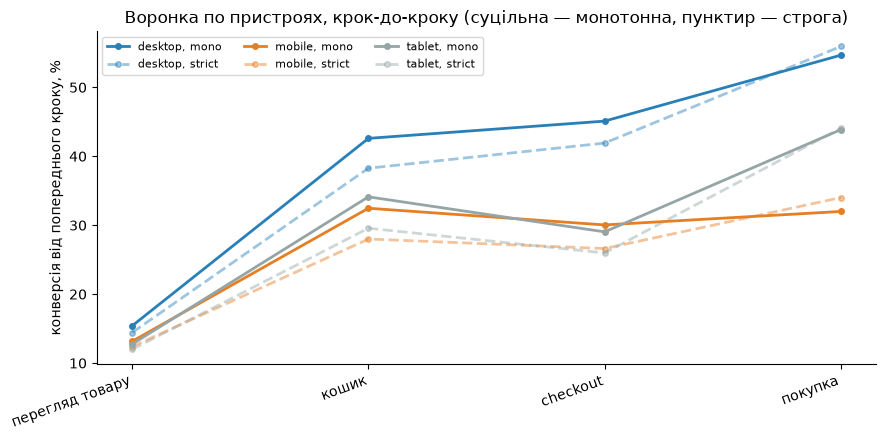

In [3]:
pair = dev[dev.device.isin(['mobile', 'desktop'])]

gaps = {}
for v in ('mono', 'strict'):
    p = pair[pair.version == v].pivot(index='device', columns='step', values='cr_step')[STEPS]
    gaps[v] = (p.loc['desktop'] - p.loc['mobile'])

gap_tbl = pd.DataFrame(gaps).T.rename(columns=STEP_UA)
gap_tbl.index = ['монотонна', 'строга']
print('Розрив desktop − mobile на кожному кроці, п.п.:')
display(gap_tbl.round(2))

# Відношення, а не тільки різниця: п.п. на кроці з конверсією 15% і на кроці
# з конверсією 55% — це різні речі, тому напрям перевіряю на обох метриках.
p_mono = pair[pair.version == 'mono'].pivot(index='device', columns='step', values='cr_step')[STEPS]
ratio = (p_mono.loc['desktop'] / p_mono.loc['mobile']).rename(STEP_UA)
print('\nВідношення desktop / mobile на кожному кроці (монотонна):')
display(ratio.round(2))

g = gap_tbl.loc['монотонна']
print(f"\nНайбільший розрив: {g.idxmax()} ({g.max():.2f} п.п.), "
      f"найменший: {g.idxmin()} ({g.min():.2f} п.п.)")
# Описова частина. Формальна перевірка — z-тест на кожному кроці + бутстреп
# на різницю останній мінус перший, як зафіксовано в hypotheses.md.

fig, ax = plt.subplots()
for device, color in [('desktop', '#2980b9'), ('mobile', '#e67e22'), ('tablet', '#95a5a6')]:
    for v, style in [('mono', '-'), ('strict', '--')]:
        g_ = dev[(dev.device == device) & (dev.version == v)].sort_values('step')
        ax.plot(range(len(STEPS)), g_.cr_step, style, marker='o', ms=4, lw=2,
                color=color, alpha=1.0 if v == 'mono' else 0.45,
                label=f'{device}, {v}')
ax.set_xticks(range(len(STEPS)))
ax.set_xticklabels([STEP_UA[s] for s in STEPS], rotation=20, ha='right')
ax.set_ylabel('конверсія від попереднього кроку, %')
ax.set_title('Воронка по пристроях, крок-до-кроку (суцільна — монотонна, пунктир — строга)')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

**Найбільший розрив desktop − mobile — на останньому кроці, найменший — на вході, і це не залежить від версії воронки.**

Монотонна: 2.25 — 10.14 — 15.06 — 22.67 п.п. Строга: 2.04 — 10.27 — 15.31 — 21.92 п.п. Дві версії дають майже однакові числа, тобто форма розриву не створена правилом дозапису кроків.

На відношеннях картина та сама: 1.17× — 1.31× — 1.50× — 1.71×. Це важливо, бо в процентних пунктах розрив на кроці з конверсією 15% і на кроці з конверсією 55% не зіставний напряму; напрям тримається на обох метриках.

Це напрям, який передбачає гіпотеза 2: телефони не програють рівномірно, вони особливо ламаються ближче до оплати. Розрив на вході, найменший член ряду, при цьому нестійкий до складу каналів — розділ 7 показує, наскільки саме, і чому висновок усе одно встоює.

Наскрізна конверсія (від старту) поводиться навпаки — звужується до кінця, як і у `01_funnel.ipynb` для каналів. Це очікуваний ефект відбору, а не спростування.

Формальна перевірка (z-тест на кожному кроці + бутстреп-інтервал на різницю останній мінус перший) робиться окремо, при перевірці гіпотез.

## 2. Конфаунд монотонності по пристроях

Той самий ефект, що в `01_funnel.ipynb`: монотонна воронка дозаписує крок «перегляд товару» лише сесіям, які дійшли далі, тому цей крок виміряний точніше для покупців. Якщо ставка дозапису різна для mobile/desktop, частина розриву на вході воронки — метод, а не поведінка.

`pct_buyers_no_view` показує ставку **серед покупців**, а дозапис отримують усі, хто дійшов до будь-якого пізнішого кроку. Тому цей показник сам по собі не переноситься на воронку — обсяг дозапису рахується прямо з `21_funnel_by_device.csv` як різниця монотонної та строгої версій.

In [4]:
cf = load('22_monotonic_confound_device.csv')
cf['device'] = cf.device.fillna('усі пристрої')
display(cf[['device', 'sessions_with_hits', 'pct_no_view',
            'purchase_sessions', 'buyers_no_view', 'pct_buyers_no_view']])

sub = cf[cf.device != 'усі пристрої'].sort_values('pct_buyers_no_view')
print(f"Розкид дозапису серед покупців: {sub.pct_buyers_no_view.min():.1f}% ({sub.device.iloc[0]}) "
      f"до {sub.pct_buyers_no_view.max():.1f}% ({sub.device.iloc[-1]})")

,device,sessions_with_hits,pct_no_view,purchase_sessions,buyers_no_view,pct_buyers_no_view
0,усі пристрої,879171,86.13,11398,2097,18.40
1,desktop,640959,85.57,10376,1881,18.13
2,mobile,207922,87.61,854,177,20.73
3,tablet,30290,88.01,168,39,23.21


Розкид дозапису серед покупців: 18.1% (desktop) до 23.2% (tablet)


In [5]:
# Скільки сесій кожного пристрою фактично отримали дозаписаний крок «перегляд»
# і на скільки це піднімає конверсію входу.
bf = d[d.device != 'усі пристрої'][['device', 'sessions', 'viewed_mono', 'viewed_strict']].copy()
bf['дозаписано сесій'] = bf.viewed_mono - bf.viewed_strict
bf['частка дозапису у монотонному кроці, %'] = 100 * bf['дозаписано сесій'] / bf.viewed_mono
bf['вхід строгий, %'] = 100 * bf.viewed_strict / bf.sessions
bf['вхід монотонний, %'] = 100 * bf.viewed_mono / bf.sessions
bf['завищення входу, п.п.'] = bf['вхід монотонний, %'] - bf['вхід строгий, %']
display(bf.set_index('device').round(2))

up_d = bf.loc[bf.device == 'desktop', 'завищення входу, п.п.'].iloc[0]
up_m = bf.loc[bf.device == 'mobile', 'завищення входу, п.п.'].iloc[0]
print(f'Метод піднімає конверсію входу для desktop на {up_d:.2f} п.п., '
      f'для mobile на {up_m:.2f} п.п. '
      f'Отже розрив на вході завищений методом на {up_d - up_m:.2f} п.п., а не занижений.')

,sessions,viewed_mono,viewed_strict,дозаписано сесій,"частка дозапису у монотонному кроці, %","вхід строгий, %","вхід монотонний, %","завищення входу, п.п."
device,,,,,,,,
desktop,640959,98774,92520,6254,6.33,14.43,15.41,0.98
mobile,207922,27366,25768,1598,5.84,12.39,13.16,0.77
tablet,30290,3866,3633,233,6.03,11.99,12.76,0.77


Метод піднімає конверсію входу для desktop на 0.98 п.п., для mobile на 0.77 п.п. Отже розрив на вході завищений методом на 0.21 п.п., а не занижений.


**Ставка дозапису серед покупців справді вища в mobile (20.73% проти 18.13% у desktop), але на воронку це впливає у зворотний бік.**

У сесіях: desktop отримує 6 254 дозаписаних кроки «перегляд», mobile — 1 598. Відносно всіх сесій пристрою це +0.98 процентного пункту до конверсії входу для desktop і +0.77 п.п. для mobile. Тобто метод завищує **desktop** сильніше, і виміряний розрив на вході (2.25 п.п. у монотонній) на 0.21 п.п. більший за строгий (2.04 п.п.).

Це прямий підрахунок, а не міркування через `pct_buyers_no_view`: та частка міряє тільки покупців, тоді як дозапис отримують усі сесії, що дійшли до кошика чи checkout, а їх у desktop непропорційно більше.

Висновок для гіпотези 2: конфаунд монотонності не пояснює форму розриву. Дві версії воронки в розділ 1 дають один і той самий патерн, різниця по кроках не перевищує 0.8 п.п. Загрозою для гіпотези 2 є не цей ефект, а склад каналів (розділ 7).

## 3. Нові проти повернених

`totals.newVisits` — `1` або `NULL`, не `0/1`; у SQL це враховано через `IFNULL`.

Рахую обидві метрики — крок-до-кроку і наскрізну. Порівнювати цей розріз із розділ 1 можна тільки на однаковій метриці: наскрізна конверсія механічно звужується в будь-якому розрізі, бо кожен наступний крок множиться на попередній.

In [6]:
r = load('23_funnel_by_returning.csv')
r['visitor_type'] = r.visitor_type.fillna('ВСІ')

check = int(r.loc[r.visitor_type == 'ВСІ', 'sessions'].iloc[0])
assert check == KEPT_SESSIONS, f'ROLLUP розійшовся з підсумком воронки: {check:,} проти {KEPT_SESSIONS:,}'

rl = to_long(r[r.visitor_type != 'ВСІ'], 'visitor_type', versions=('mono',))

for metric, name in [('cr_step', 'крок-до-кроку'), ('cr_overall', 'наскрізна')]:
    print(f'\nКонверсія {name}, %')
    display(rl.pivot(index='visitor_type', columns='step', values=metric)
              .rename(columns=STEP_UA).round(2))

pv = rl.pivot(index='visitor_type', columns='step', values='cr_step')[STEPS]
diff = (pv.loc['повернений'] - pv.loc['новий']).rename(STEP_UA)
print('\nРозрив повернені − нові, крок-до-кроку, п.п.:')
display(diff.round(2))


Конверсія крок-до-кроку, %


step,перегляд товару,кошик,checkout,покупка
visitor_type,,,,
новий,12.45,35.10,34.60,42.53
повернений,23.32,50.16,52.40,60.02



Конверсія наскрізна, %


step,перегляд товару,кошик,checkout,покупка
visitor_type,,,,
новий,12.45,4.37,1.51,0.64
повернений,23.32,11.70,6.13,3.68



Розрив повернені − нові, крок-до-кроку, п.п.:


step
перегляд товару   10.87
кошик             15.06
checkout          17.80
покупка           17.48
dtype: float64

**Повернені сильніші на кожному кроці; розрив росте до кошика й checkout, а далі перестає збільшуватися.**

Крок-до-кроку розрив повернені − нові: 10.87 — 15.06 — 17.80 — 17.48 п.п. Це не «рівномірно на всіх кроках», але й не той патерн, що в розділ 1: там розрив росте до самого кінця (22.67 п.п. на останньому кроці), тут між третім і четвертим кроком він уже не збільшується.

На наскрізній конверсії розріз поводиться так само, як пристрої: 10.87 — 7.33 — 4.62 — 3.04 п.п., тобто звужується. Різниця між двома розрізами видно тільки на крок-до-кроку, і саме тому порівнювати їх на різних метриках не можна.

Підсумкова цифра: наскрізно повернені конвертують у 5.7 раза краще (3.68% проти 0.64%), і перевага помітна вже на вході — 23.32% проти 12.45%.

## 4. Топ-5 країн

Воронка тільки для країн, що набирають найбільше сесій.

Про поріг. У `hypotheses.md` зафіксовано: канал не тестується на кроці, де в нього менше 100 **сесій**. Усі п'ять країн проходять цей поріг із запасом, тому він тут нічого не відсіює. Нижче застосовано інше правило — щонайменше 100 **подій на самому кроці**: частка рахується від кількості подій на кроці, і саме вона визначає, скільки в ній шуму. Це post-hoc правило, воно описове й на перевірку гіпотез не поширюється (та сама помітка, що для порогу в 100 покупок у `01_funnel.ipynb`).

In [7]:
c = load('24_top_countries.csv')
c['cr_purchase'] = 100 * c.purchase_mono / c.sessions

step_cols = ['viewed_mono', 'cart_mono', 'checkout_mono', 'purchase_mono']
assert (c.sessions >= 100).all(), 'Є країна нижче пре-реєстрованого порогу 100 сесій'

below = c[c[step_cols].lt(100).any(axis=1)]
if len(below):
    print('Країни, у яких хоча б один крок має менше 100 подій — крок не інтерпретувати:')
    display(below[['country', 'sessions'] + step_cols])

display(c[['country', 'sessions', 'viewed_mono', 'checkout_mono', 'purchase_mono', 'cr_purchase']]
        .round(3))

Країни, у яких хоча б один крок має менше 100 подій — крок не інтерпретувати:


,country,sessions,viewed_mono,cart_mono,checkout_mono,purchase_mono
1,India,49983,5245,2119,611,10
2,United Kingdom,36533,3280,1024,288,16
4,Vietnam,24514,369,99,18,0


,country,sessions,viewed_mono,checkout_mono,purchase_mono,cr_purchase
0,United States,355620,83829,16900,10838,3.05
1,India,49983,5245,611,10,0.02
2,United Kingdom,36533,3280,288,16,0.04
3,Canada,25001,5530,793,191,0.76
4,Vietnam,24514,369,18,0,0.00


**Надійні цифри є тільки для US і Canada; India, UK і Vietnam — недостатньо подій на пізніх кроках.**

`India` (10 покупок) і `UK` (16) провалюють крок «покупка» — до checkout включно в них ще нормальні лічильники. `Vietnam` провалює вже сам checkout (18 подій), по ньому не можна казати нічого, крім «майже нуль на кожному кроці». `US` (10 838 покупок) і `Canada` (191) — єдині, для кого конверсію в покупку можна інтерпретувати: 3.05% і 0.76%.

Твердження «в Індії конверсія 0.02%» будувалось би на 10 подіях і в текст не йде.

## 5. Перетин канал × пристрій

Комірок 21: сім каналів на три пристрої.

Поріг перевіряю по кількості покупок, а не сесій. Конверсія рахується від покупок, тому саме їхня кількість визначає, чи має число сенс: комірка з 14 803 сесіями і 7 покупками формально проходить пре-реєстрований поріг по сесіях, але 0.047% на семи подіях нічого не значить. Це post-hoc правило, описове, на перевірку гіпотез не поширюється — так само, як у `01_funnel.ipynb`.

In [8]:
cross = load('25_channel_device_cross.csv')

# У запиті 25 крок «перегляд» рахується без GREATEST, тобто це строга версія.
# У ранній вивантаженні колонка називалася viewed_mono помилково — приймаю обидві назви.
VIEW_COL = 'viewed_strict' if 'viewed_strict' in cross.columns else 'viewed_mono'
if VIEW_COL == 'viewed_mono':
    print('УВАГА: у CSV стара назва viewed_mono. Це строгий крок «перегляд», '
          'а не монотонний — перевивантаж 25 після правки SQL.')

assert cross.sessions.sum() == KEPT_SESSIONS, 'Перетин розійшовся з підсумком воронки'

pivot_sessions  = cross.pivot(index='channel', columns='device', values='sessions')
pivot_purchases = cross.pivot(index='channel', columns='device', values='purchase_mono')
pivot_cr        = cross.pivot(index='channel', columns='device', values='cr_pct')

mask = pivot_purchases < 100
n_cells = mask.size
n_below = int(mask.sum().sum())
print(f'Комірок усього: {n_cells}. Нижче порогу 100 покупок: {n_below}. '
      f'Проходять: {n_cells - n_below}.')

display(pivot_sessions.fillna(0).astype(int))
print()
display(pivot_purchases.fillna(0).astype(int))

print('\nКонверсія, %  (NaN — нижче порогу 100 покупок, не інтерпретувати)')
display(pivot_cr.round(3).where(~mask, other=float('nan')))

ok = (cross[cross.purchase_mono >= 100]
      .sort_values('cr_pct', ascending=False)[['channel', 'device', 'sessions',
                                               'purchase_mono', 'cr_pct']])
print('\nКомірки, що проходять поріг, за спаданням конверсії:')
display(ok.reset_index(drop=True))

Комірок усього: 21. Нижче порогу 100 покупок: 13. Проходять: 8.


device,desktop,mobile,tablet
channel,,,
Affiliates,14803,1361,208
Direct,87980,49504,5372
Display,4564,1536,159
Organic Search,245480,117517,18140
Paid Search,12657,10532,2101
Referral,77743,4543,549
Social,197732,22929,3761


device,desktop,mobile,tablet
channel,,,
Affiliates,7,2,0
Direct,1800,223,37
Display,134,9,0
Organic Search,2823,513,107
Paid Search,359,93,17
Referral,5199,9,5
Social,54,5,2



Конверсія, %  (NaN — нижче порогу 100 покупок, не інтерпретувати)


device,desktop,mobile,tablet
channel,,,
Affiliates,NaN,NaN,NaN
Direct,2.05,0.45,NaN
Display,2.94,NaN,NaN
Organic Search,1.15,0.44,0.59
Paid Search,2.84,NaN,NaN
Referral,6.69,NaN,NaN
Social,NaN,NaN,NaN



Комірки, що проходять поріг, за спаданням конверсії:


,channel,device,sessions,purchase_mono,cr_pct
0,Referral,desktop,77743,5199,6.69
1,Display,desktop,4564,134,2.94
2,Paid Search,desktop,12657,359,2.84
3,Direct,desktop,87980,1800,2.05
4,Organic Search,desktop,245480,2823,1.15
5,Organic Search,tablet,18140,107,0.59
6,Direct,mobile,49504,223,0.45
7,Organic Search,mobile,117517,513,0.44


**Поріг ≥100 покупок проходять 8 комірок з 21; серед них Referral-desktop (6.687%) виділяється найбільше.**

Надійні комірки за спаданням конверсії: Referral-desktop 6.687%, Display-desktop 2.936%, Paid Search-desktop 2.836%, Direct-desktop 2.046%, Organic Search-desktop 1.150%, Organic Search-tablet 0.590%, Direct-mobile 0.450%, Organic Search-mobile 0.437%. Решта 13 комірок — Affiliates повністю, Social повністю, Display і Paid Search на mobile/tablet, Referral на mobile/tablet — менше 100 покупок; наприклад Affiliates-desktop має 14 803 сесії і сім покупок.

Referral-desktop (6.69%) майже дорівнює загальній конверсії Referral з `01_funnel.ipynb` (6.3%), і за тим самим механізмом: цей перетин не ділить Referral на «прихований direct» і «збережене джерело», тому 6.69% тут найімовірніше знову переважно той самий бакет hidden-direct, а не властивість «рефералів на десктопі» як таких. Щоб стверджувати щось про Referral-desktop окремо, потрібен додатковий перетин з `direct_sourced`.

Друге, що видно з таблиці сесій і що важить більше: сім з восьми надійних комірок — desktop. Це не властивість каналів, це склад трафіку, і саме він розбирається в розділ 7.

## 6. Повернені по каналах

,channel,sessions,returning_sessions,pct_returning
6,Display,6259,4382,70.00
3,Referral,82835,41027,49.50
4,Paid Search,25290,9547,37.80
2,Direct,142856,36139,25.30
5,Affiliates,16372,3884,23.70
0,Organic Search,381137,78809,20.70
1,Social,224422,15398,6.90


Повернених за visitNumber > 1: 189,186; за IFNULL(totals.newVisits, 0) != 1: 189,186.
Два незалежні поля дають те саме число — вибір означення на висновки не впливає.


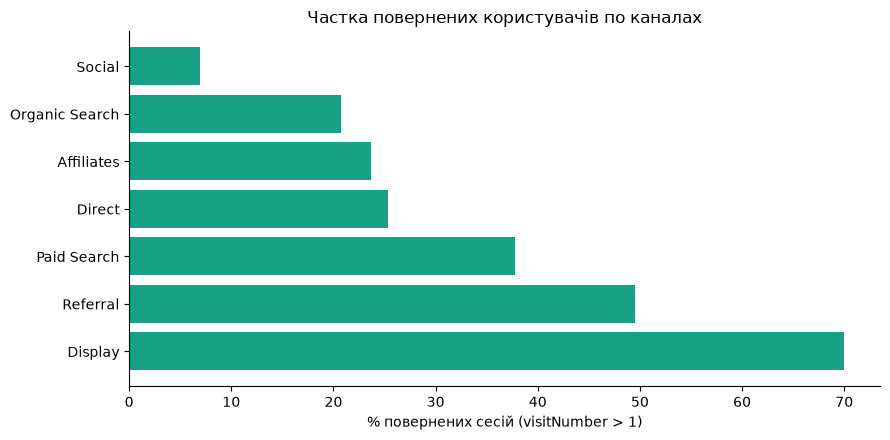

In [9]:
ret = load('26_return_share_by_channel.csv').sort_values('pct_returning', ascending=False)
display(ret)

# Порівняння двох означень «повернений»: розділ 3 бере totals.newVisits, розділ 6 — visitNumber > 1.
by_visit_number = int(ret.returning_sessions.sum())
by_new_visits = int(r.loc[r.visitor_type == 'повернений', 'sessions'].iloc[0])
print(f'Повернених за visitNumber > 1: {by_visit_number:,}; '
      f'за IFNULL(totals.newVisits, 0) != 1: {by_new_visits:,}.')
assert by_visit_number == by_new_visits, 'Два означення повернених розійшлися'
print('Два незалежні поля дають те саме число — вибір означення на висновки не впливає.')

fig, ax = plt.subplots()
ax.barh(ret.channel, ret.pct_returning, color='#16a085')
ax.set_xlabel('% повернених сесій (visitNumber > 1)')
ax.set_title('Частка повернених користувачів по каналах')
plt.tight_layout()
plt.show()

**49.5% повернених у Referral — не властивість каналу, а той самий артефакт переприписування атрибуції.**

З `15_direct_source_vs_channel.csv`: канал на 83.1% складається з сесій із прихованим джерелом (`source='(direct)'`), і саме вони мають аномально високу частку повернених — 55.6% (`pct_return_direct`). Справжні реферали, де джерело збереглося, повертаються лише в 19.6% випадків (`pct_return_rest`) — практично на рівні Organic Search (20.7%). Зважена сума підтверджує це напряму: 0.831 × 55.6 + 0.169 × 19.6 = 49.5% — точно те число, що вийшло тут. Розбіжності немає: це один факт, порахований на двох рівнях агрегації.

Для контрасту: Display показує 70.0% повернених і майже те саме число (`pct_return_rest` = 70.4%) при мізерній частці прихованого direct (1.2% каналу). Тут висока «повернутість» — справжня властивість каналу (ретаргетингова реклама здебільшого й показується тим, хто вже був на сайті), а не наслідок атрибуції. Без цього зіставлення розділ 6 виглядав би так, ніби Referral і Display — однаковий тип каналу «для лояльних», хоча природа протилежна: одне вимірювальний артефакт, інше реальна поведінка.

Окремо: два означення повернених (`totals.newVisits` у розділ 3 і `visitNumber > 1` тут) дають однакове число до сесії — 189 186. Це не було закладено, поля незалежні, тому збіг працює як перевірка означення.

## 7. Чи не є розрив між пристроями розривом між каналами
Два відомі артефакти вибірки лежать на desktop непропорційно. Referral без джерела — 12.1% сесій desktop проти 2.2% сесій mobile, і саме він дав 45.1% усіх покупок вибірки. Social — це на 94.7% youtube з майже нульовою конверсією, і він становить 30.9% сесій desktop проти 11.0% сесій mobile.

Перший роздуває розрив унизу воронки, другий стискає його на вході. Обидва зміщують результат у той бік, який робить гіпотезу 2 підтвердженою, тому їх треба порахувати окремо, а не лишати в агрегаті.

Крок «перегляд» і покупку можна перерахувати прямо з `25_channel_device_cross.csv`. Кошика і checkout там немає — для них потрібен окремий запит (`27_funnel_by_device_variants.csv`).

In [10]:
# Розклад по варіантах на тих кроках, що вже є в перетині 25.
# Крок «перегляд» тут строгий, тому порівнювати треба зі строгим рядком розділ 1 (2.04 п.п.).
variants = {
    'усі канали':  cross,
    'без Social':  cross[cross.channel != 'Social'],
    'без Referral': cross[cross.channel != 'Referral'],
    'без обох':    cross[~cross.channel.isin(['Social', 'Referral'])],
}

rows = []
for label, sub_df in variants.items():
    g = (sub_df[sub_df.device.isin(['desktop', 'mobile'])]
         .groupby('device')[['sessions', VIEW_COL, 'purchase_mono']].sum())
    entry = 100 * g[VIEW_COL] / g.sessions
    cr = 100 * g.purchase_mono / g.sessions
    rows.append({
        'варіант': label,
        'сесій desktop': int(g.sessions['desktop']),
        'сесій mobile': int(g.sessions['mobile']),
        'вхід desktop, %': entry['desktop'],
        'вхід mobile, %': entry['mobile'],
        'розрив входу, п.п.': entry['desktop'] - entry['mobile'],
        'CR desktop, %': cr['desktop'],
        'CR mobile, %': cr['mobile'],
        'CR desktop / mobile': cr['desktop'] / cr['mobile'],
    })

vt = pd.DataFrame(rows).set_index('варіант')
display(vt[['сесій desktop', 'сесій mobile']])
display(vt[['вхід desktop, %', 'вхід mobile, %', 'розрив входу, п.п.']].round(2))
display(vt[['CR desktop, %', 'CR mobile, %', 'CR desktop / mobile']].round(3))

,сесій desktop,сесій mobile
варіант,,
усі канали,640959,207922
без Social,443227,184993
без Referral,563216,203379
без обох,365484,180450


,"вхід desktop, %","вхід mobile, %","розрив входу, п.п."
варіант,,,
усі канали,14.43,12.39,2.04
без Social,20.19,13.18,7.01
без Referral,12.05,12.40,-0.36
без обох,17.73,13.21,4.52


,"CR desktop, %","CR mobile, %",CR desktop / mobile
варіант,,,
усі канали,1.62,0.41,3.94
без Social,2.33,0.46,5.07
без Referral,0.92,0.41,2.21
без обох,1.40,0.47,3.01


Що саме прибирає кожен варіант:


,прибрано сесій,з них desktop,"частка desktop, %"
варіант,,,
Referral без джерела,68860,68395,99.30
без Social,224422,197732,88.10
без обох,293282,266127,90.70



Розрив desktop − mobile по кроках, версія mono, п.п.


,перегляд товару,кошик,checkout,покупка
variant,,,,
Referral без джерела,-0.31,6.92,8.57,15.01
без Social,7.60,10.33,14.43,22.83
без обох,4.81,7.07,7.92,15.36
усі,2.25,10.14,15.06,22.67



Розрив desktop − mobile по кроках, версія strict, п.п.


,перегляд товару,кошик,checkout,покупка
variant,,,,
Referral без джерела,-0.35,7.01,8.65,13.87
без Social,7.01,10.19,15.04,22.14
без обох,4.41,6.91,8.35,14.30
усі,2.04,10.27,15.31,21.92


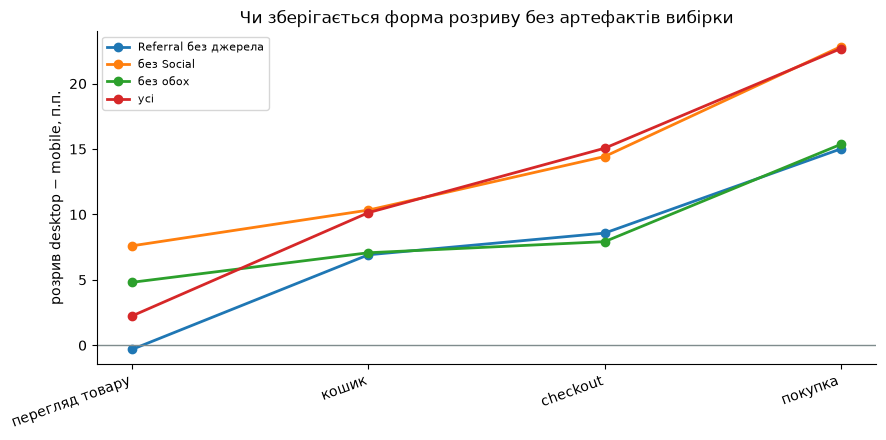

In [11]:
# Повна воронка по пристроях у чотирьох варіантах — потрібен запит 27 з sql/02_segments.sql.
P27 = DATA / '27_funnel_by_device_variants.csv'

if not P27.exists():
    print('27_funnel_by_device_variants.csv ще не вивантажено.\n'
          'Без нього кошик і checkout у варіантах без артефактів не порахувати, '
          'і форма розриву в гіпотезі 2 лишається невизначеною.')
else:
    fv = pd.read_csv(P27)
    BASE = 'усі'
    total_all = int(fv.loc[fv.variant == BASE, 'sessions'].sum())
    assert total_all == KEPT_SESSIONS, f'Варіант «{BASE}» розійшовся: {total_all:,}'

    # Наскільки нерівномірно кожен варіант б'є по пристроях. Якщо прибрані
    # сесії майже цілком десктопні, воно не може не впливати на розрив.
    base_sessions = fv[fv.variant == BASE].set_index('device').sessions
    removed = []
    for variant, sub_df in fv[fv.variant != BASE].groupby('variant'):
        rem = base_sessions - sub_df.set_index('device').sessions
        removed.append({'варіант': variant, 'прибрано сесій': int(rem.sum()),
                        'з них desktop': int(rem['desktop']),
                        'частка desktop, %': 100 * rem['desktop'] / rem.sum()})
    print('Що саме прибирає кожен варіант:')
    display(pd.DataFrame(removed).set_index('варіант').round(1))

    parts = []
    for variant, sub_df in fv.groupby('variant'):
        lv = to_long(sub_df[sub_df.device.isin(['desktop', 'mobile'])], 'device')
        lv['variant'] = variant
        parts.append(lv)
    lv = pd.concat(parts)

    for v in ('mono', 'strict'):
        piv = (lv[lv.version == v]
               .pivot_table(index='variant', columns=['step', 'device'], values='cr_step'))
        gap = pd.DataFrame({STEP_UA[s]: piv[(s, 'desktop')] - piv[(s, 'mobile')] for s in STEPS})
        print(f'\nРозрив desktop − mobile по кроках, версія {v}, п.п.')
        display(gap.round(2))

    fig, ax = plt.subplots()
    piv = (lv[lv.version == 'mono']
           .pivot_table(index='variant', columns=['step', 'device'], values='cr_step'))
    for variant in piv.index:
        vals = [piv.loc[variant, (s, 'desktop')] - piv.loc[variant, (s, 'mobile')] for s in STEPS]
        ax.plot(range(len(STEPS)), vals, marker='o', lw=2, label=variant)
    ax.axhline(0, color='#7f8c8d', lw=1)
    ax.set_xticks(range(len(STEPS)))
    ax.set_xticklabels([STEP_UA[s] for s in STEPS], rotation=20, ha='right')
    ax.set_ylabel('розрив desktop − mobile, п.п.')
    ax.set_title('Чи зберігається форма розриву без артефактів вибірки')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

**Форма розриву стійка: у всіх чотирьох варіантах вибірки розрив desktop − mobile росте від кроку до кроку, і максимум завжди на «checkout — покупка».**

Монотонна воронка, розрив desktop − mobile у п.п.:

| варіант | перегляд | кошик | checkout | покупка | останній − перший |
|---|---|---|---|---|---|
| усі канали | 2.25 | 10.14 | 15.06 | 22.67 | 20.42 |
| без Social | 7.60 | 10.33 | 14.43 | 22.83 | 15.23 |
| Referral без джерела | −0.31 | 6.92 | 8.57 | 15.01 | 15.32 |
| без обох | 4.81 | 7.07 | 7.92 | 15.36 | 10.55 |

Строга версія дає ті самі знаки й майже ті самі величини (останній − перший: 19.88 / 15.13 / 14.22 / 9.89), тому вибір версії воронки тут нічого не вирішує.

Пре-реєстрована статистика гіпотези 2 — розрив на останньому кроці мінус розрив на першому — додатна в кожному варіанті: від 10.55 до 20.42 п.п. Гіпотеза не спростовується жодним із них. Але амплітуда відрізняється вдвічі, і найбільше число (20.42 на всіх каналах) — найменш надійне з чотирьох, бо воно найсильніше спирається на артефакт.

Чому саме на нього. Бакет Referral без джерела на **99.3% десктопний**: із 68 860 сесій 68 395 — desktop, 442 — mobile, 23 — tablet. Це не «трохи більше на десктопі», це сегмент, якого в мобільному трафіку практично немає. Він же несе 5 129 із 10 376 покупок desktop, тобто половину. Тому будь-яке порівняння пристроїв на повній вибірці частково порівнює цей бакет із його відсутністю.

Застереження, яке треба назвати. На процентних пунктах (пре-реєстрована метрика) розрив росте монотонно скрізь. На відношеннях desktop/mobile — ні: без Social ряд виглядає як 1.55 — 1.32 — 1.46 — 1.70, тобто вхід уже не найменший, а провалюється середина. Останній крок лишається максимумом у всіх чотирьох варіантах на обох метриках, тож умова підтвердження з `hypotheses.md` («розрив на останньому кроці помітно більший за розрив на першому») виконується. Але частина зростання в п.п. — арифметика: базова конверсія кроку росте донизу воронки, і той самий відносний програш дає більше процентних пунктів. У блоці 4 це варто показати поруч, а не ховати.

**Що з цього йде у перевірку гіпотез.** Z-тест і бутстреп на різницю останній мінус перший рахуються двічі: на варіанті «усі» і на варіанті «Referral без джерела». Social лишається в обох — youtube це реальний трафік реального магазину, а не артефакт вимірювання; його вплив описується в README, а не виключається з тесту.

Окремо для README: те, що бакет майже повністю десктопний, саме по собі цікаве. У блоці 1 версію «внутрішній трафік компанії» відкинуто за провайдерами, і це рішення лишається, але розподіл по пристроях — ще одна ознака, що бакет не випадковий. На висновки це не впливає, у список обмежень датасету — варте рядка.

## Що це дало гіпотезам

**Гіпотеза 2 (mobile програють на пізніших кроках) — напрям підтверджується описово і витримує перевірку на артефакти.** Розрив desktop − mobile росте від кроку до кроку в усіх чотирьох варіантах вибірки, максимум завжди на «checkout — покупка», пре-реєстрована різниця останній-мінус-перший додатна скрізь (10.55–20.42 п.п.). Це не артефакт монотонного дозапису: строга версія дає ту саму картину, а розділ 2 показує, що метод завищує вхідний розрив на 0.21 п.п., а не занижує. Два застереження, обидва в розділ 7: на повній вибірці ефект завищений майже вдвічі бакетом Referral без джерела, який на 99.3% десктопний; і на відношеннях, замість процентних пунктів, зростання не монотонне. Формальна перевірка (z-тест + бутстреп) робиться окремо, на двох варіантах вибірки.

**Побічні знахідки, що впливають на інтерпретацію інших розрізів:**

- Нові/повернені (розділ 3) — окремий механізм: розрив росте до кошика і checkout, далі перестає збільшуватися (10.87 — 15.06 — 17.80 — 17.48 п.п.), тоді як у пристроях він росте до самого кінця. Порівняння коректне тільки на крок-до-кроку: на наскрізній обидва розрізи звужуються однаково.
- Топ-5 країн (розділ 4) — три з п'яти не проходять поріг у 100 подій на кроці: `Vietnam` уже на checkout, `India` і `UK` на покупці. Надійні тільки `US` (3.05%) і `Canada` (0.76%).
- Канал × пристрій (розділ 5) — 13 з 21 комірки нижче порогу 100 покупок. Серед восьми надійних сім — desktop, і найпомітніша, `Referral-desktop` (6.69%), найімовірніше несе той самий hidden-direct артефакт з `01_funnel.ipynb`.
- Повернені по каналах (розділ 6) — `Referral` 49.5% це майже повністю ефект переприписування direct-трафіку (55.6% всередині прихованого бакету проти 19.6% у справжніх рефералів). `Display` 70% — навпаки, справжня поведінкова риса каналу.

**Що з цього випливає для наступних розрізів.** Перед тим як тлумачити будь-яке число, варто перевірити дві речі: чи не тримається воно на сесіях із прихованим джерелом і чи вистачає в комірці подій. Тут це знадобилося тричі — у розділах 5, 6 і 7. У сьомому перевірка не спростувала висновок, а показала, наскільки він завищений: 20.42 проти 15.32 процентного пункту.